In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
# Truco para que Jupyter lea siempre la última versión de la carpeta src/
%load_ext autoreload
%autoreload 2

In [13]:
from src.data_loader import loader
from src.model_trainer import optimizar_hiperparametros_modelo
from src.evaluator import evaluar_modelo

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import joblib
import src.config as config
import pandas as pd
from xgboost import XGBClassifier


In [4]:
X_train, X_test, y_train, y_test = loader(OHE=True)

print("¡Datos cargados con éxito! Tamaño de entrenamiento:", X_train.shape)

¡Datos cargados con éxito! Tamaño de entrenamiento: (95189, 422)


#### Decisision Tree Classifier

In [23]:
dt_base = DecisionTreeClassifier(random_state=0)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

mejor_arbol, hiperparametros = optimizar_hiperparametros_modelo(dt_base, param_grid_dt, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

¡Entrenamiento terminado! Los mejores parámetros son:
 {'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}



	  Reporte de clasificación (Entrenamiento) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     59897
           1       0.86      0.82      0.84     35292

    accuracy                           0.88     95189
   macro avg       0.88      0.87      0.88     95189
weighted avg       0.88      0.88      0.88     95189


	  Reporte de clasificación (Test) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     14975
           1       0.82      0.78      0.80      8823

    accuracy                           0.85     23798
   macro avg       0.85      0.84      0.84     23798
weighted avg       0.85      0.85      0.85     23798



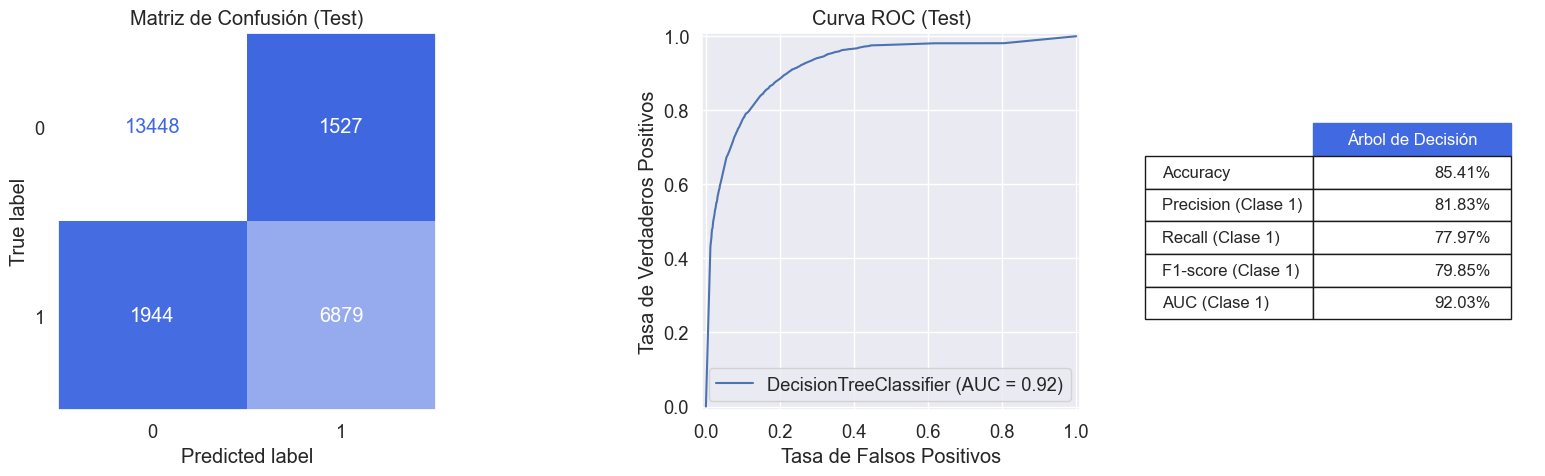

In [24]:
# Métricas de evaluación
evaluar_modelo(mejor_arbol, X_train, X_test, y_train, y_test, 'Árbol de Decisión')

In [31]:
#Guardo las metricas principales de modelo de clasificación
from src.evaluator import calcular_metricas


arbol_results = calcular_metricas(mejor_arbol, X_test, y_test, 'Decision Tree Classifier')
arbol_results

,Decision Tree Classifier
Accuracy,85.41%
Precision (Clase 1),81.83%
Recall (Clase 1),77.97%
F1-score (Clase 1),79.85%
AUC (Clase 1),92.03%


In [ ]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# Guardar el árbol ganador usando la ruta de tu config.py
joblib.dump(mejor_arbol, config.DT_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.DT_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\tree.pkl!


#### RandomForestCalssifier
- se hace una búsqueda de hiperparámetros óptimos vía GridSearchCV
- se saca la importancia de las features en la clasificación
- se scan las métricas de clasificación
- se serializa el modelo en un pkl

In [5]:
modelo_rfc = RandomForestClassifier()

dict_parametros = {
    'n_estimators': [50, 100, 300],
    'max_depth': [8,10,12], #[6,8,10],
    'class_weight': ['balanced'],
    'n_jobs': [-1]
}
# Entrenamiento de un modelo de RandomForest Classifier
mejor_rfc, hiperparametros = optimizar_hiperparametros_modelo(modelo_rfc, dict_parametros, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

¡Entrenamiento terminado! Los mejores parámetros son:
 {'class_weight': 'balanced', 'max_depth': 12, 'n_estimators': 300, 'n_jobs': -1}



	  Reporte de clasificación (Entrenamiento) - RandomForestClassifier
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.89      0.89     59897
           1       0.81      0.80      0.81     35292

    accuracy                           0.86     95189
   macro avg       0.85      0.85      0.85     95189
weighted avg       0.86      0.86      0.86     95189


	  Reporte de clasificación (Test) - RandomForestClassifier
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     14975
           1       0.81      0.79      0.80      8823

    accuracy                           0.85     23798
   macro avg       0.84      0.84      0.84     23798
weighted avg       0.85      0.85      0.85     23798



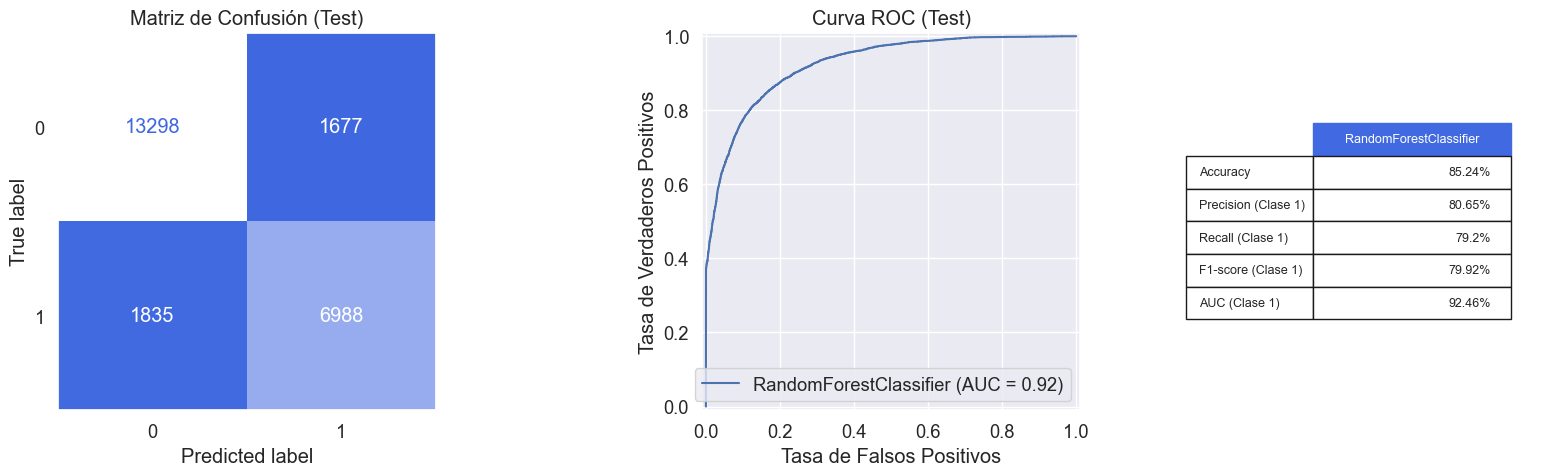

In [6]:
# Métricas de evaluación

evaluar_modelo(mejor_rfc, X_train, X_test, y_train, y_test, 'RandomForestClassifier')

In [30]:
#Guardo las metricas principales de modelo de clasificación
from src.evaluator import calcular_metricas


mejor_randomForest = calcular_metricas(mejor_rfc, X_test, y_test, 'RandomForestCalssifier')
mejor_randomForest

,RandomForestCalssifier
Accuracy,85.24%
Precision (Clase 1),80.65%
Recall (Clase 1),79.2%
F1-score (Clase 1),79.92%
AUC (Clase 1),92.46%


In [ ]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# Guardar rfc ganador usando la ruta de tu config.py
joblib.dump(mejor_rfc, config.RFC_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.RFC_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\RandomForestClassifierModel.pkl!


In [11]:
# Feature importance
importances = mejor_rfc.feature_importances_
feature_imp = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
feature_imp.head(15)

,Feature,Gini Importance
45,deposit_type_Non Refund,0.130686
14,country_PRT,0.120522
409,lead_time,0.094508
420,total_of_special_requests,0.082991
414,previous_cancellations,0.049745
419,required_car_parking_spaces,0.042406
18,market_segment_Groups,0.032392
407,customer_type_Transient,0.029812
416,booking_changes,0.029356
408,customer_type_Transient-Party,0.026446


#### XGBoost

In [15]:
# proporción exacta de desbalanceo
total_negativos = (y_train == 0).sum()
total_positivos = (y_train == 1).sum()
peso_cancelaciones = total_negativos / total_positivos

print(f"Peso calculado para XGBoost (scale_pos_weight): {peso_cancelaciones:.2f}")

Peso calculado para XGBoost (scale_pos_weight): 1.70


In [ ]:
# modelo
xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_cancelaciones,
    eval_metric='logloss',
    n_jobs=-1
)

In [17]:
# Cuadrícula para que no tarde
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

In [18]:
print("Entrenando XGBoost... (Esto puede tardar unos minutos)")

mejor_xgb, hiperparametros_xgb = optimizar_hiperparametros_modelo(
    xgb_base, 
    param_grid_xgb, 
    X_train, 
    y_train
)

print('\n¡Entrenamiento terminado!')
print('Mejores hiperparámetros encontrados:', hiperparametros_xgb)

Entrenando XGBoost... (Esto puede tardar unos minutos)

¡Entrenamiento terminado!
Mejores hiperparámetros encontrados: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}



	  Reporte de clasificación (Entrenamiento) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     59897
           1       0.84      0.91      0.87     35292

    accuracy                           0.90     95189
   macro avg       0.89      0.90      0.90     95189
weighted avg       0.90      0.90      0.90     95189


	  Reporte de clasificación (Test) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     14975
           1       0.81      0.87      0.84      8823

    accuracy                           0.87     23798
   macro avg       0.86      0.87      0.87     23798
weighted avg       0.88      0.87      0.88     23798



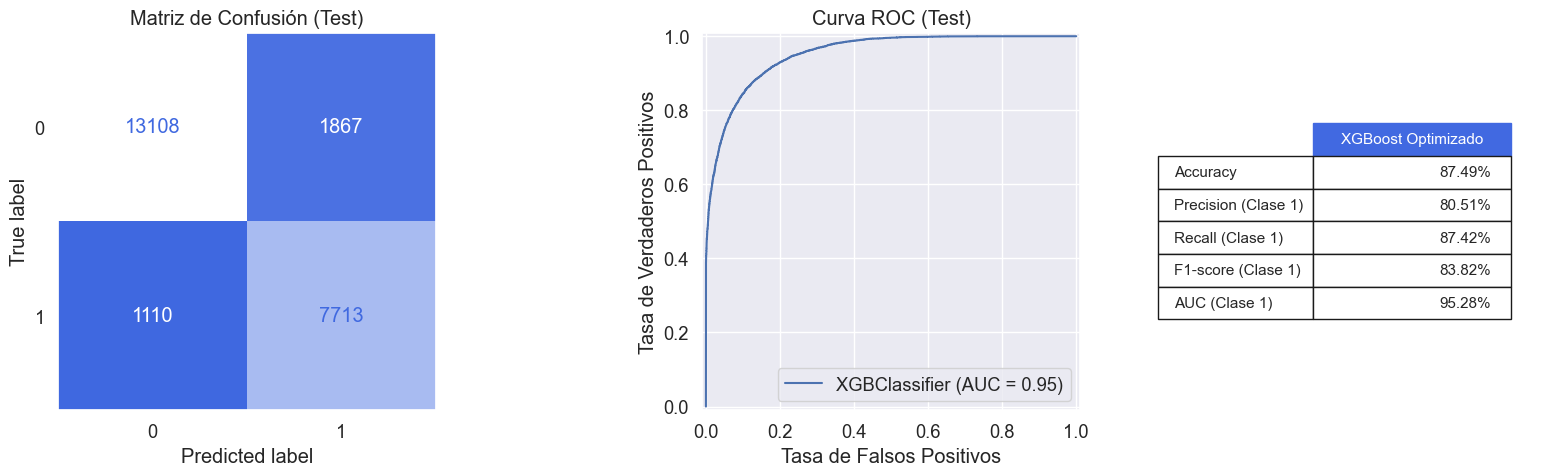

In [19]:
# Evaluación del modelo XGBoost
evaluar_modelo(mejor_xgb, X_train, X_test, y_train, y_test, 'XGBoost Optimizado')

In [29]:
#Guardo las metricas principales de modelo de clasificación
from src.evaluator import calcular_metricas


mejor_xgboost = calcular_metricas(mejor_xgb, X_test, y_test, 'XGBoost')
mejor_xgboost


,XGBoost
Accuracy,87.49%
Precision (Clase 1),80.51%
Recall (Clase 1),87.42%
F1-score (Clase 1),83.82%
AUC (Clase 1),95.28%


In [20]:
# Creo la carpeta tests si no existe
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# Ruta para XGBoost
XGB_MODEL_PATH = config.MODELS_TEST_DIR / 'XGBoostModel.pkl'

# Guardar el modelo ganador
joblib.dump(mejor_xgb, XGB_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {XGB_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\XGBoostModel.pkl!


In [ ]:
import json

# Cojo la primera fila de X_test para simular un cliente real. (Caso: 1)
cliente_real = X_test.iloc[0:1].to_dict(orient="records")

# Lo formateo como JSON limpio
json_para_api = json.dumps({"datos": cliente_real})
print(json_para_api)

{"datos": [{"hotel_Resort Hotel": 0.0, "meal_FB": 0.0, "meal_HB": 0.0, "meal_SC": 0.0, "meal_Undefined": 0.0, "country_BRA": 0.0, "country_DEU": 0.0, "country_ESP": 0.0, "country_FRA": 0.0, "country_GBR": 0.0, "country_IRL": 0.0, "country_ITA": 0.0, "country_NLD": 0.0, "country_Other": 0.0, "country_PRT": 1.0, "market_segment_Complementary": 0.0, "market_segment_Corporate": 0.0, "market_segment_Direct": 0.0, "market_segment_Groups": 0.0, "market_segment_Offline TA/TO": 0.0, "market_segment_Online TA": 1.0, "market_segment_Undefined": 0.0, "distribution_channel_Direct": 0.0, "distribution_channel_GDS": 0.0, "distribution_channel_TA/TO": 1.0, "distribution_channel_Undefined": 0.0, "is_repeated_guest_1": 0.0, "reserved_room_type_B": 0.0, "reserved_room_type_C": 0.0, "reserved_room_type_D": 0.0, "reserved_room_type_E": 0.0, "reserved_room_type_F": 1.0, "reserved_room_type_G": 0.0, "reserved_room_type_H": 0.0, "reserved_room_type_L": 0.0, "assigned_room_type_B": 0.0, "assigned_room_type_C":

In [33]:
import json

# Busco un caso 0
predicciones_test = mejor_xgb.predict(X_test)

# Cliente 0 (No cancela) 
indice_cliente_cero = (predicciones_test == 0).argmax()

# Cojo el cliente
cliente_seguro = X_test.iloc[indice_cliente_cero:indice_cliente_cero+1].to_dict(orient="records")

json_cliente_seguro = json.dumps({"datos": cliente_seguro})
print(json_cliente_seguro)

{"datos": [{"hotel_Resort Hotel": 1.0, "meal_FB": 0.0, "meal_HB": 1.0, "meal_SC": 0.0, "meal_Undefined": 0.0, "country_BRA": 0.0, "country_DEU": 0.0, "country_ESP": 0.0, "country_FRA": 0.0, "country_GBR": 0.0, "country_IRL": 0.0, "country_ITA": 0.0, "country_NLD": 0.0, "country_Other": 0.0, "country_PRT": 1.0, "market_segment_Complementary": 0.0, "market_segment_Corporate": 0.0, "market_segment_Direct": 0.0, "market_segment_Groups": 0.0, "market_segment_Offline TA/TO": 0.0, "market_segment_Online TA": 1.0, "market_segment_Undefined": 0.0, "distribution_channel_Direct": 0.0, "distribution_channel_GDS": 0.0, "distribution_channel_TA/TO": 1.0, "distribution_channel_Undefined": 0.0, "is_repeated_guest_1": 1.0, "reserved_room_type_B": 0.0, "reserved_room_type_C": 0.0, "reserved_room_type_D": 0.0, "reserved_room_type_E": 0.0, "reserved_room_type_F": 0.0, "reserved_room_type_G": 1.0, "reserved_room_type_H": 0.0, "reserved_room_type_L": 0.0, "assigned_room_type_B": 0.0, "assigned_room_type_C":